##### Author: Pablo Iañez Picazo
##### Biomedical Data Science lab

In [1]:
# Load all the necessary libraries

from glob import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from statannotations.Annotator import Annotator

# Supress all warnings (bcoz they're quite annoying)
import warnings

warnings.filterwarnings("ignore")

from hsc_spatial_stats import *

In [2]:
sns.set(rc={'figure.figsize':(20, 16)})
sns.set_style("whitegrid")

In [8]:
# ------------------------ Set up some parameters --------------------------- #
# Image resolution after resizing, which is 5 micrometers per pixel
res = 0.1
# cluster forming threshold - threshold at which intensities above this value
# will be considered belonging to a DAPI-Intense Region (DIR)
# Intensities to 0.6 are the one in the quantile 0.80 in young, old and treated
cft = 0.6
normalization = "z_score"
folder = "data"
conditions = [
    "young",
    "old",
    "treated_RhoAi",
]

palette = {
    "Young": (0.00392, 0.45098, 0.69803),
    "Aged": (0.00784, 0.61960, 0.45098),
    "Aged + Ri": (0.8, 0.47058, 0.73725),
    "8μm": (0.79215, 0.56862, 0.38039),
    "5μm": (0.87058, 0.56078, 0.01960),
    "3μm": (0.83529, 0.36862, 0.0),
}

In [9]:
nuc_df = pd.read_csv(
    f"results/ZSCORENORM_nuclei_3d_res{res}_cf{cft}_df.csv", index_col=0
)
nuc_df = fix_labels(nuc_df)

In [10]:
features = [
    "volume",
    "extent",
    "equivalent_diameter",
    "width",
    "length",
    "height",
    "height_deviation",
    "aspect_ratio",
    "major_axis_length",
    "minor_axis_length",
    "min_intensity",
    "max_intensity",
    "solidity",
    "surface_area",
    "sphericity",
    "DIRs_volume",
    "DIRs_width",
    "DIRs_length",
    "DIRs_height",
    "DIRs_aspect_ratio",
    "DIRs_surface_area",
    "DIRs_major_axis_length",
    "DIRs_sphericity",
    "DIRs_surface/volume",
    "DIRs_mean_intensity",
    "DIRs_max_intensity",
    "DIRs_solidity",
    "DIRs_centroid_distance2border",
    "DIRs_mean_distance2border",
    "DIRs_n",
    "2D_slide_area",
    "2D_slide_major_axis_length",
    "2D_slide_minor_axis_length",
    "2D_slide_perimeter",
    "2D_slide_roundness",
    "2D_slide_EOP",
    "2D_slide_equivalent_diameter",
    "int_ratio",
    "condition",
    "im_path",
    "im_batch",
]

print(len(features[:-3]))

nuc_df = nuc_df[
    nuc_df["condition"].isin(["Young", "Aged", "Aged + Ri", "8μm", "5μm", "3μm"])
]
my_df = nuc_df[features]

# Drop columns that contain NaN values
my_df = my_df.dropna()

38


p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:2.684e-01 U_stat=1.193e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:5.579e-07 U_stat=5.960e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:7.816e-07 U_stat=7.391e+03


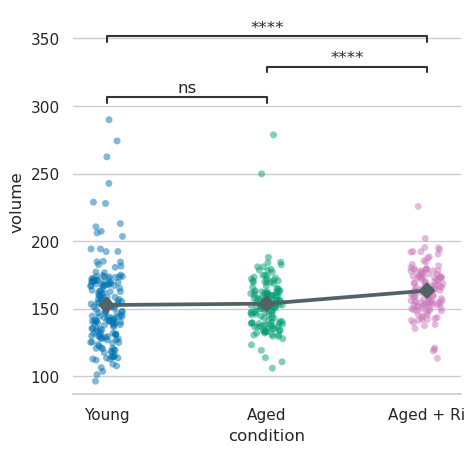

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:5.922e-01 U_stat=1.240e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:4.220e-01 U_stat=9.718e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:7.631e-01 U_stat=1.131e+04


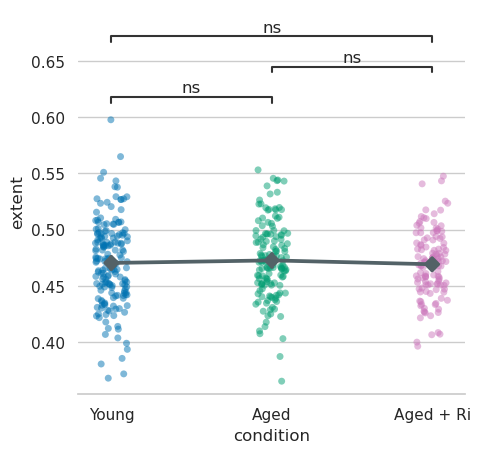

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:2.684e-01 U_stat=1.193e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:5.579e-07 U_stat=5.960e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:7.816e-07 U_stat=7.391e+03


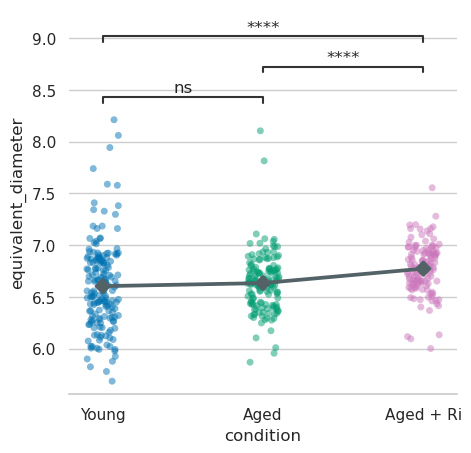

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:6.486e-01 U_stat=1.247e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:1.504e-03 U_stat=7.148e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:1.404e-03 U_stat=8.700e+03


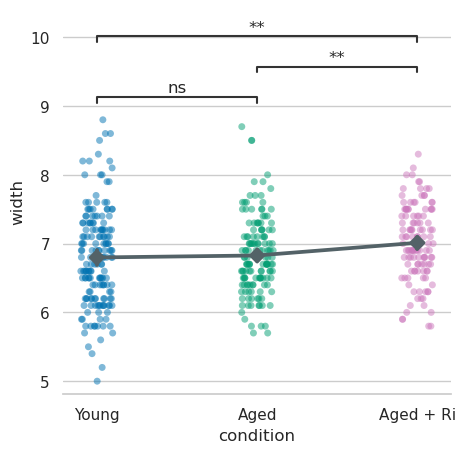

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:1.546e-02 U_stat=1.084e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:1.606e-02 U_stat=7.642e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:4.564e-06 U_stat=7.662e+03


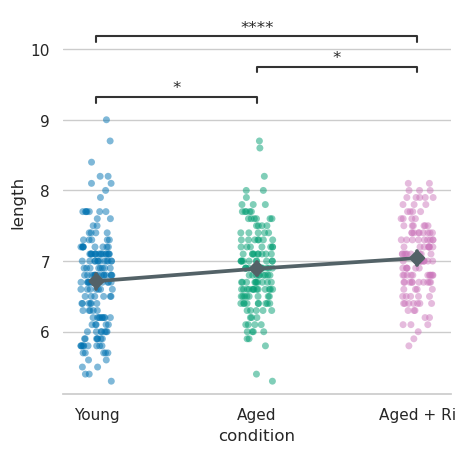

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:7.763e-02 U_stat=1.431e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:9.176e-02 U_stat=8.108e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:9.952e-01 U_stat=1.109e+04


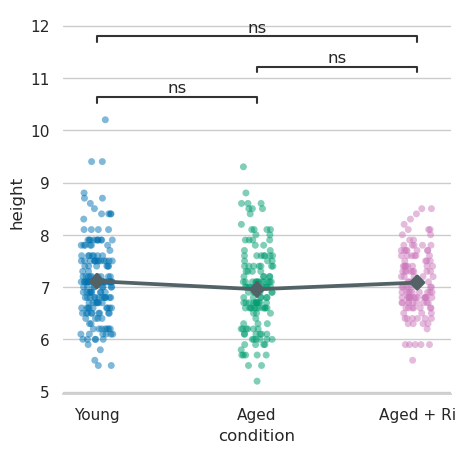

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:1.647e-01 U_stat=1.400e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:2.595e-01 U_stat=8.468e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:8.479e-01 U_stat=1.123e+04


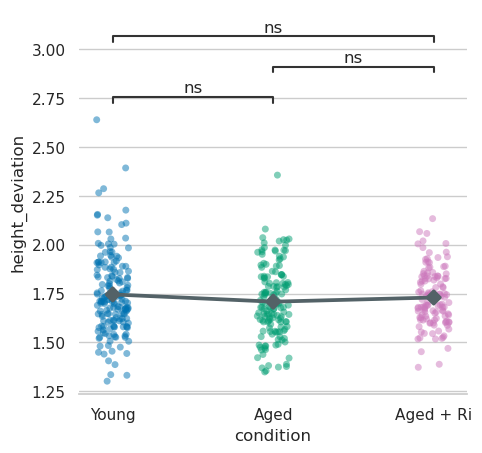

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:4.450e-03 U_stat=1.521e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:9.433e-01 U_stat=9.244e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:4.192e-03 U_stat=1.323e+04


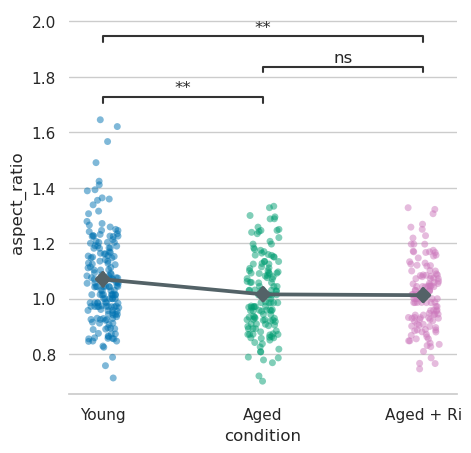

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:7.937e-01 U_stat=1.263e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:1.490e-01 U_stat=8.264e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:1.104e-01 U_stat=9.893e+03


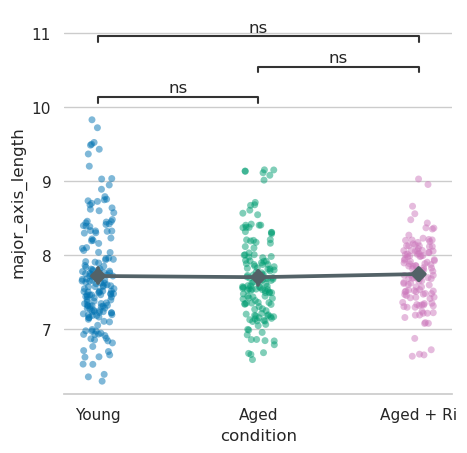

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:1.740e-01 U_stat=1.172e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:2.307e-04 U_stat=6.815e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:3.342e-06 U_stat=7.609e+03


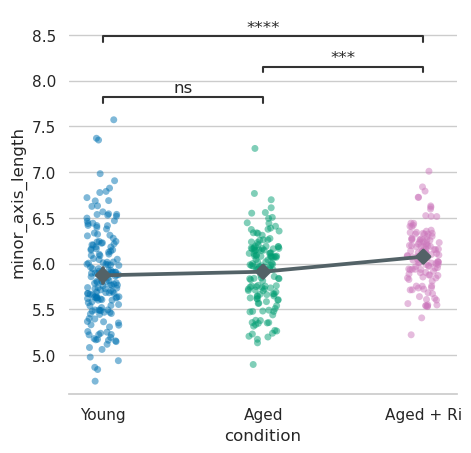

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:8.753e-01 U_stat=1.272e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:3.192e-13 U_stat=4.484e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:4.159e-16 U_stat=5.001e+03


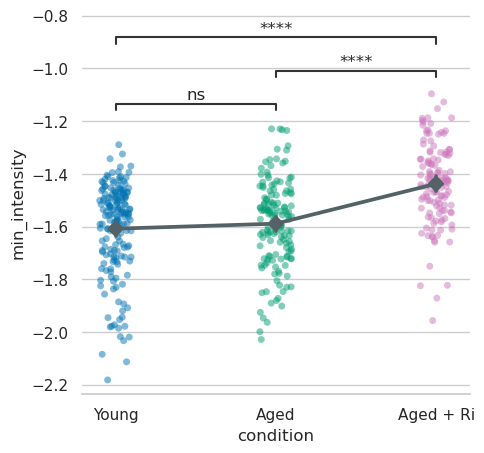

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:6.982e-01 U_stat=1.317e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:3.989e-03 U_stat=7.335e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:3.537e-02 U_stat=9.513e+03


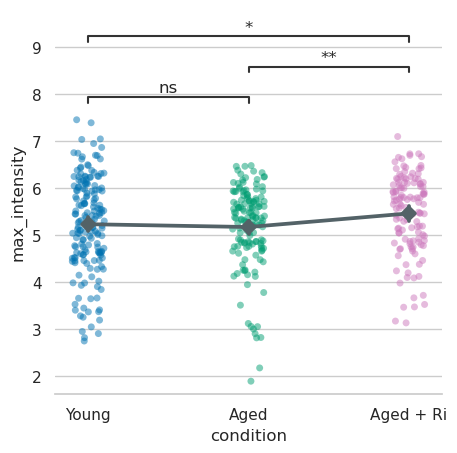

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:4.477e-01 U_stat=1.348e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:4.506e-02 U_stat=7.901e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:1.668e-01 U_stat=1.005e+04


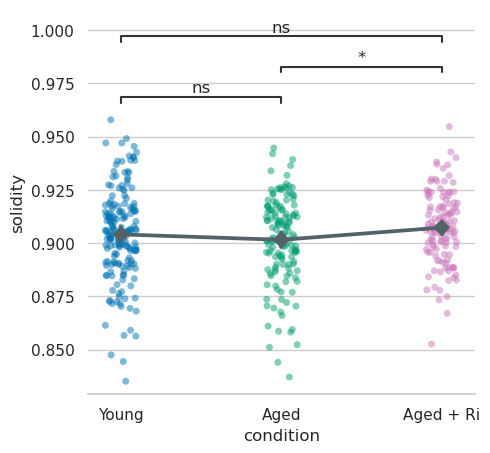

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:1.140e-01 U_stat=1.153e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:6.948e-05 U_stat=6.624e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:4.243e-06 U_stat=7.646e+03


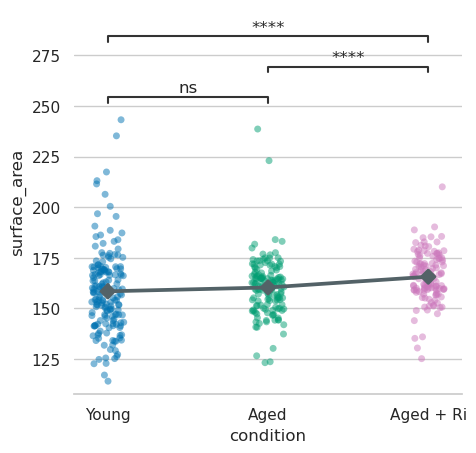

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:4.307e-02 U_stat=1.453e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:1.205e-03 U_stat=7.103e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:2.383e-01 U_stat=1.020e+04


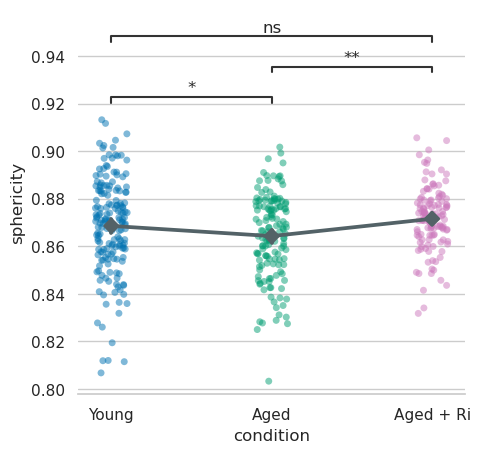

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:7.824e-04 U_stat=1.005e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:4.424e-02 U_stat=1.050e+04
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:2.050e-01 U_stat=1.014e+04


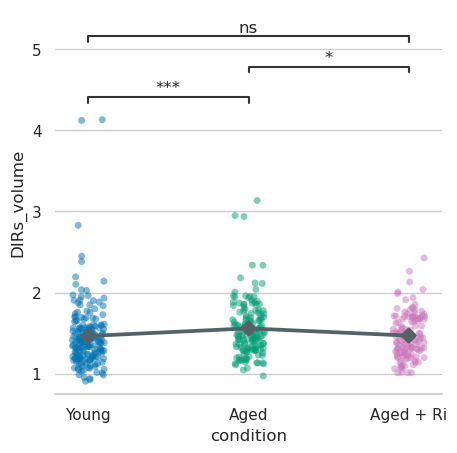

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:5.517e-01 U_stat=1.235e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:1.630e-01 U_stat=1.010e+04
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:4.062e-01 U_stat=1.171e+04


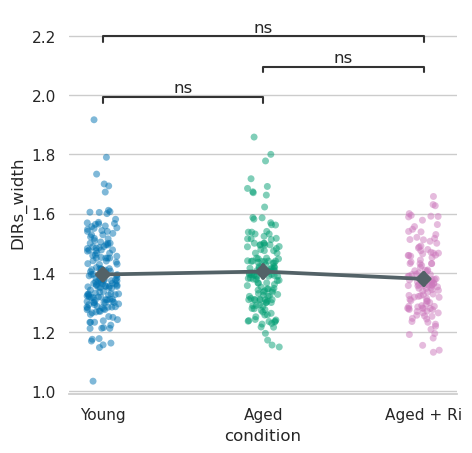

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:2.620e-02 U_stat=1.100e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:6.316e-02 U_stat=1.040e+04
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:7.591e-01 U_stat=1.086e+04


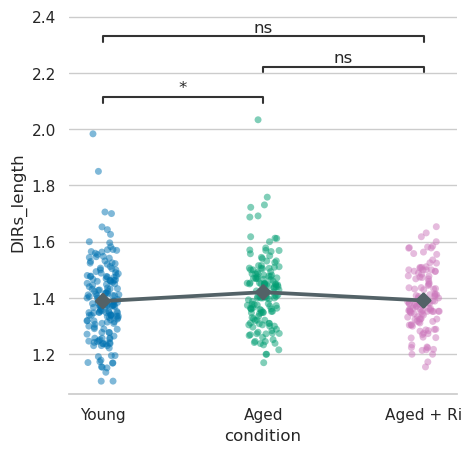

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:8.576e-03 U_stat=1.066e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:2.191e-03 U_stat=1.118e+04
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:6.949e-01 U_stat=1.138e+04


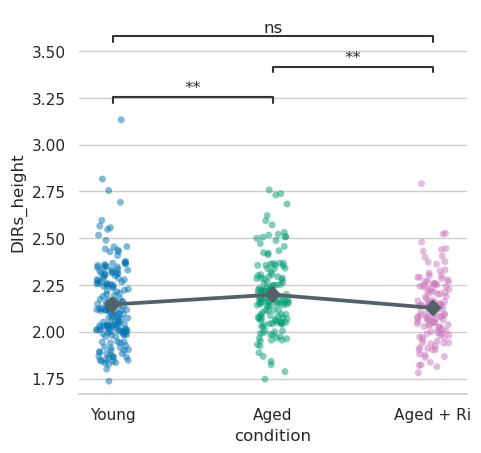

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:3.909e-01 U_stat=1.213e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:1.607e-01 U_stat=1.011e+04
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:4.968e-01 U_stat=1.160e+04


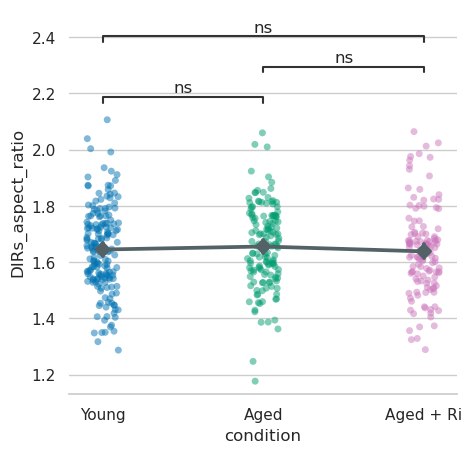

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:5.594e-01 U_stat=1.236e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:2.063e-01 U_stat=8.380e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:7.111e-02 U_stat=9.737e+03


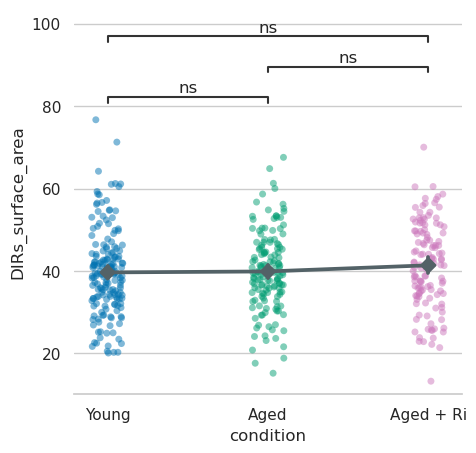

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:2.001e-02 U_stat=1.091e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:5.650e-04 U_stat=1.143e+04
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:2.535e-01 U_stat=1.194e+04


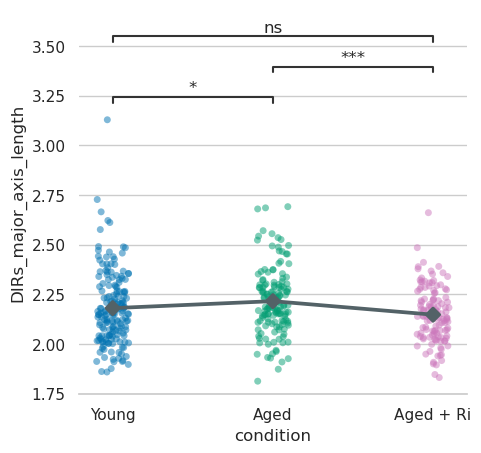

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:2.322e-01 U_stat=1.185e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:1.633e-02 U_stat=1.075e+04
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:2.585e-01 U_stat=1.193e+04


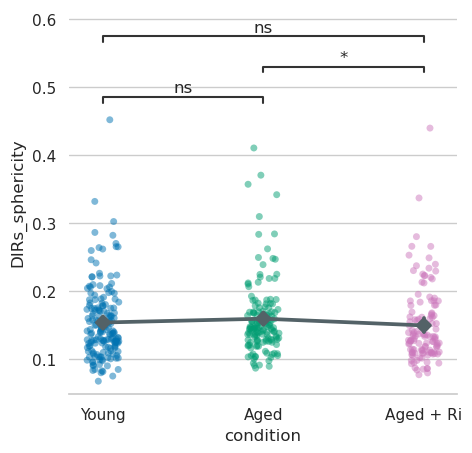

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:3.003e-01 U_stat=1.371e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:1.198e-02 U_stat=7.572e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:1.887e-01 U_stat=1.010e+04


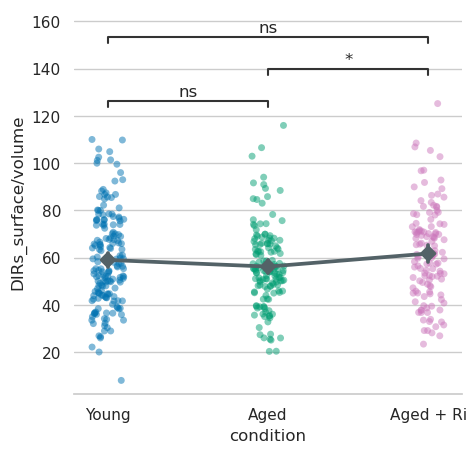

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:1.415e-02 U_stat=1.081e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:5.187e-01 U_stat=8.780e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:3.233e-03 U_stat=8.884e+03


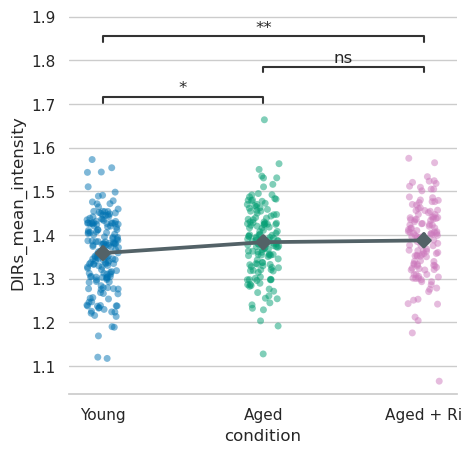

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:5.340e-02 U_stat=1.124e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:7.437e-01 U_stat=8.986e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:3.065e-02 U_stat=9.470e+03


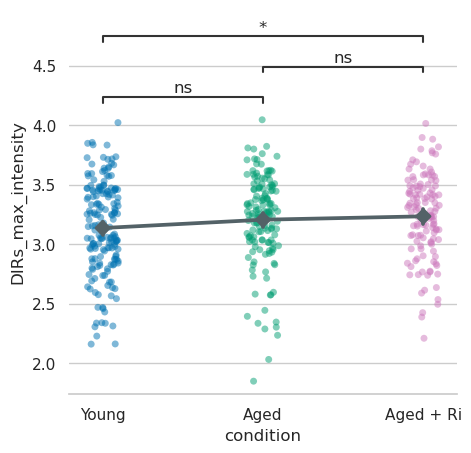

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:3.157e-01 U_stat=1.201e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:5.838e-02 U_stat=7.973e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:3.434e-03 U_stat=8.898e+03


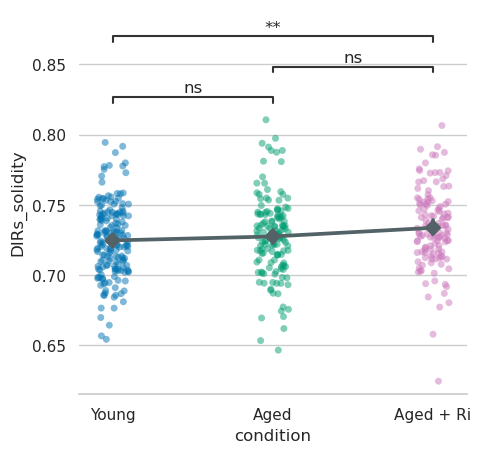

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:1.530e-03 U_stat=1.021e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:3.298e-01 U_stat=9.829e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:3.952e-02 U_stat=9.547e+03


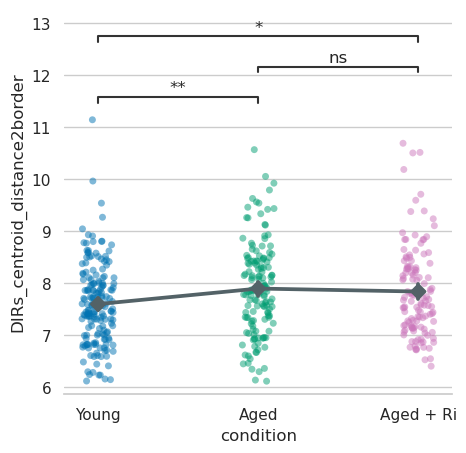

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:3.174e-04 U_stat=9.853e+03
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:2.361e-01 U_stat=9.965e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:3.991e-02 U_stat=9.550e+03


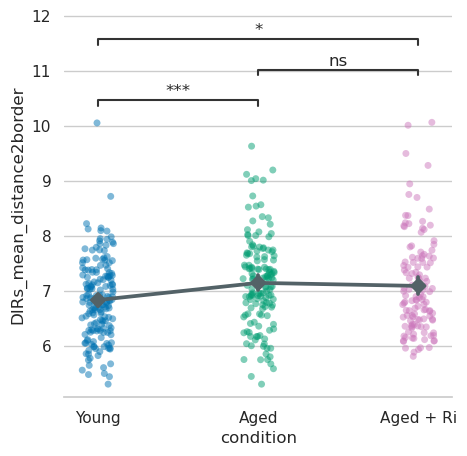

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:5.933e-03 U_stat=1.513e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:3.538e-03 U_stat=7.316e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:7.612e-01 U_stat=1.086e+04


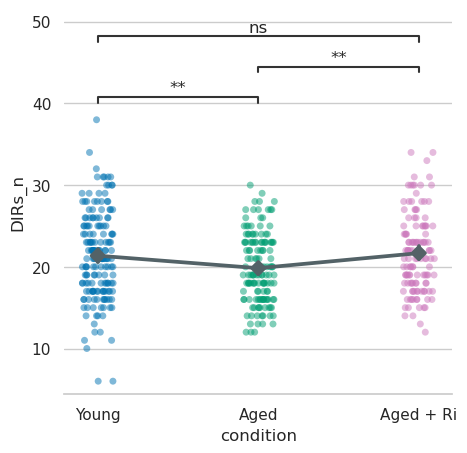

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:4.220e-02 U_stat=1.116e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:4.699e-04 U_stat=6.935e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:6.414e-06 U_stat=7.711e+03


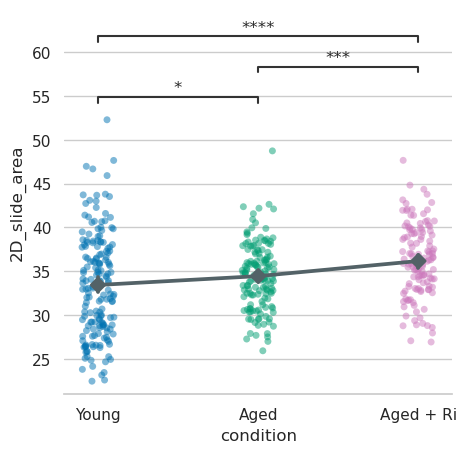

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:5.613e-02 U_stat=1.126e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:9.053e-03 U_stat=7.509e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:6.323e-05 U_stat=8.094e+03


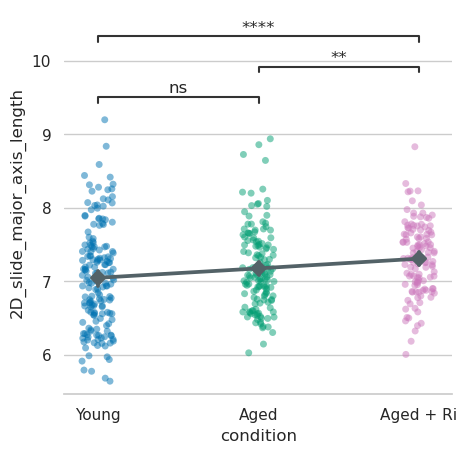

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:9.195e-02 U_stat=1.145e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:2.505e-03 U_stat=7.242e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:1.975e-05 U_stat=7.894e+03


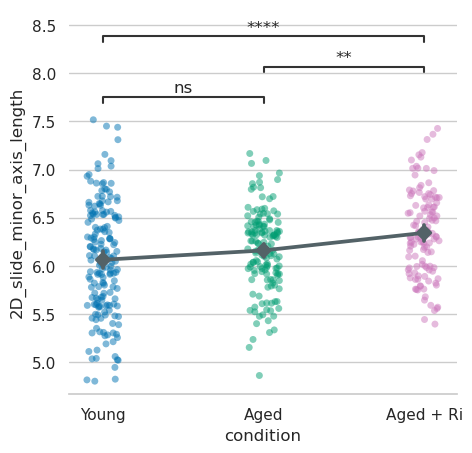

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:7.825e-02 U_stat=1.138e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:6.637e-05 U_stat=6.617e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:3.577e-06 U_stat=7.620e+03


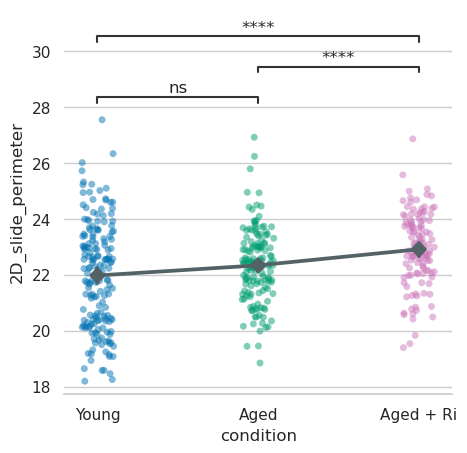

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:5.699e-01 U_stat=1.238e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:1.593e-01 U_stat=1.011e+04
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:4.859e-01 U_stat=1.161e+04


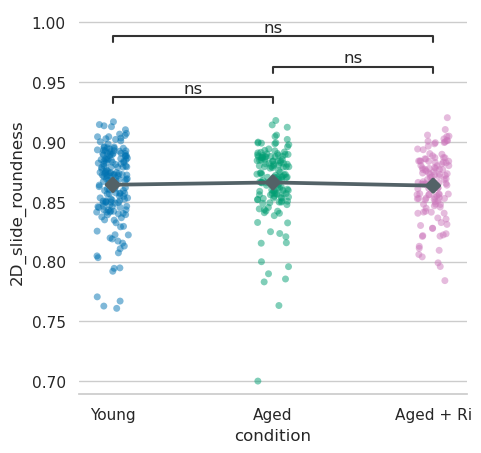

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:4.807e-01 U_stat=1.344e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:2.446e-02 U_stat=7.742e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:1.219e-01 U_stat=9.930e+03


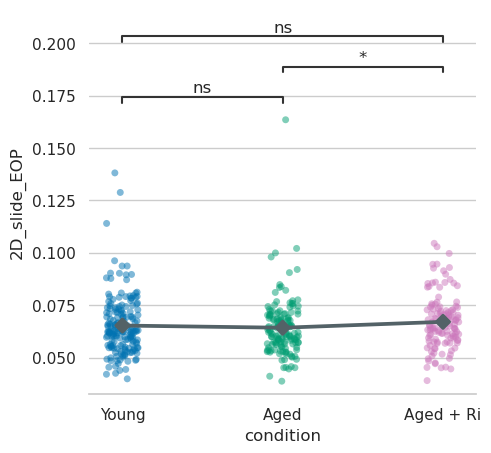

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:4.220e-02 U_stat=1.116e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:4.699e-04 U_stat=6.935e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:6.414e-06 U_stat=7.711e+03


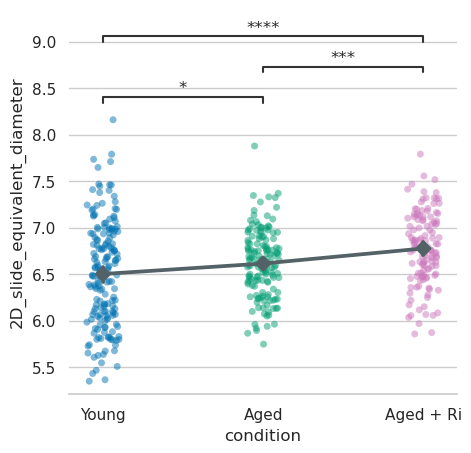

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Young vs. Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:2.045e-06 U_stat=1.680e+04
Aged vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:2.948e-05 U_stat=6.495e+03
Young vs. Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:7.581e-01 U_stat=1.086e+04


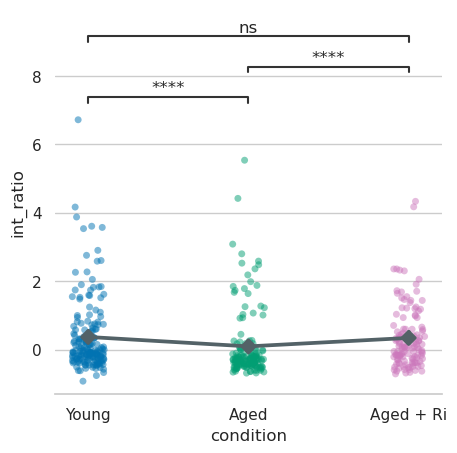

In [11]:
subset_df = nuc_df[nuc_df["condition"].isin(["Young", "Aged", "Aged + Ri"])]
subset_df = subset_df.reset_index(drop=True)

# Drop columns that contain NaN values
subset_df = subset_df.dropna()

pairs = [("Young", "Aged"), ("Aged", "Aged + Ri"), ("Young", "Aged + Ri")]

for m in features[:-3]:
    fig, ax = plt.subplots(figsize=(5, 5))
    sns.stripplot(
        data=subset_df,
        x="condition",
        y=m,
        hue="condition",
        dodge=False,
        palette=palette,
        alpha=0.5,
        zorder=1,
        ax=ax,
    )
    b = sns.pointplot(
        data=subset_df,
        x="condition",
        y=m,
        ax=ax,
        markers="D",
        dodge=False,
        color="#536267",
        errorbar="se",
        plot_kws=dict(alpha=0.3),
    )

    # If seaborn keeps plotting in a separate axis, use plt.gca() to get current axis
    annotator = Annotator(ax=b, data=subset_df, x="condition", y=m, pairs=pairs)
    annotator.configure(
        test="Mann-Whitney",
        text_format="star",
        loc="inside",
        # comparisons_correction="Bonferroni"
    )
    annotator.apply_and_annotate()

    # Delete the legend
    b.get_legend().remove()
    sns.despine(left=True)
    plt.show()

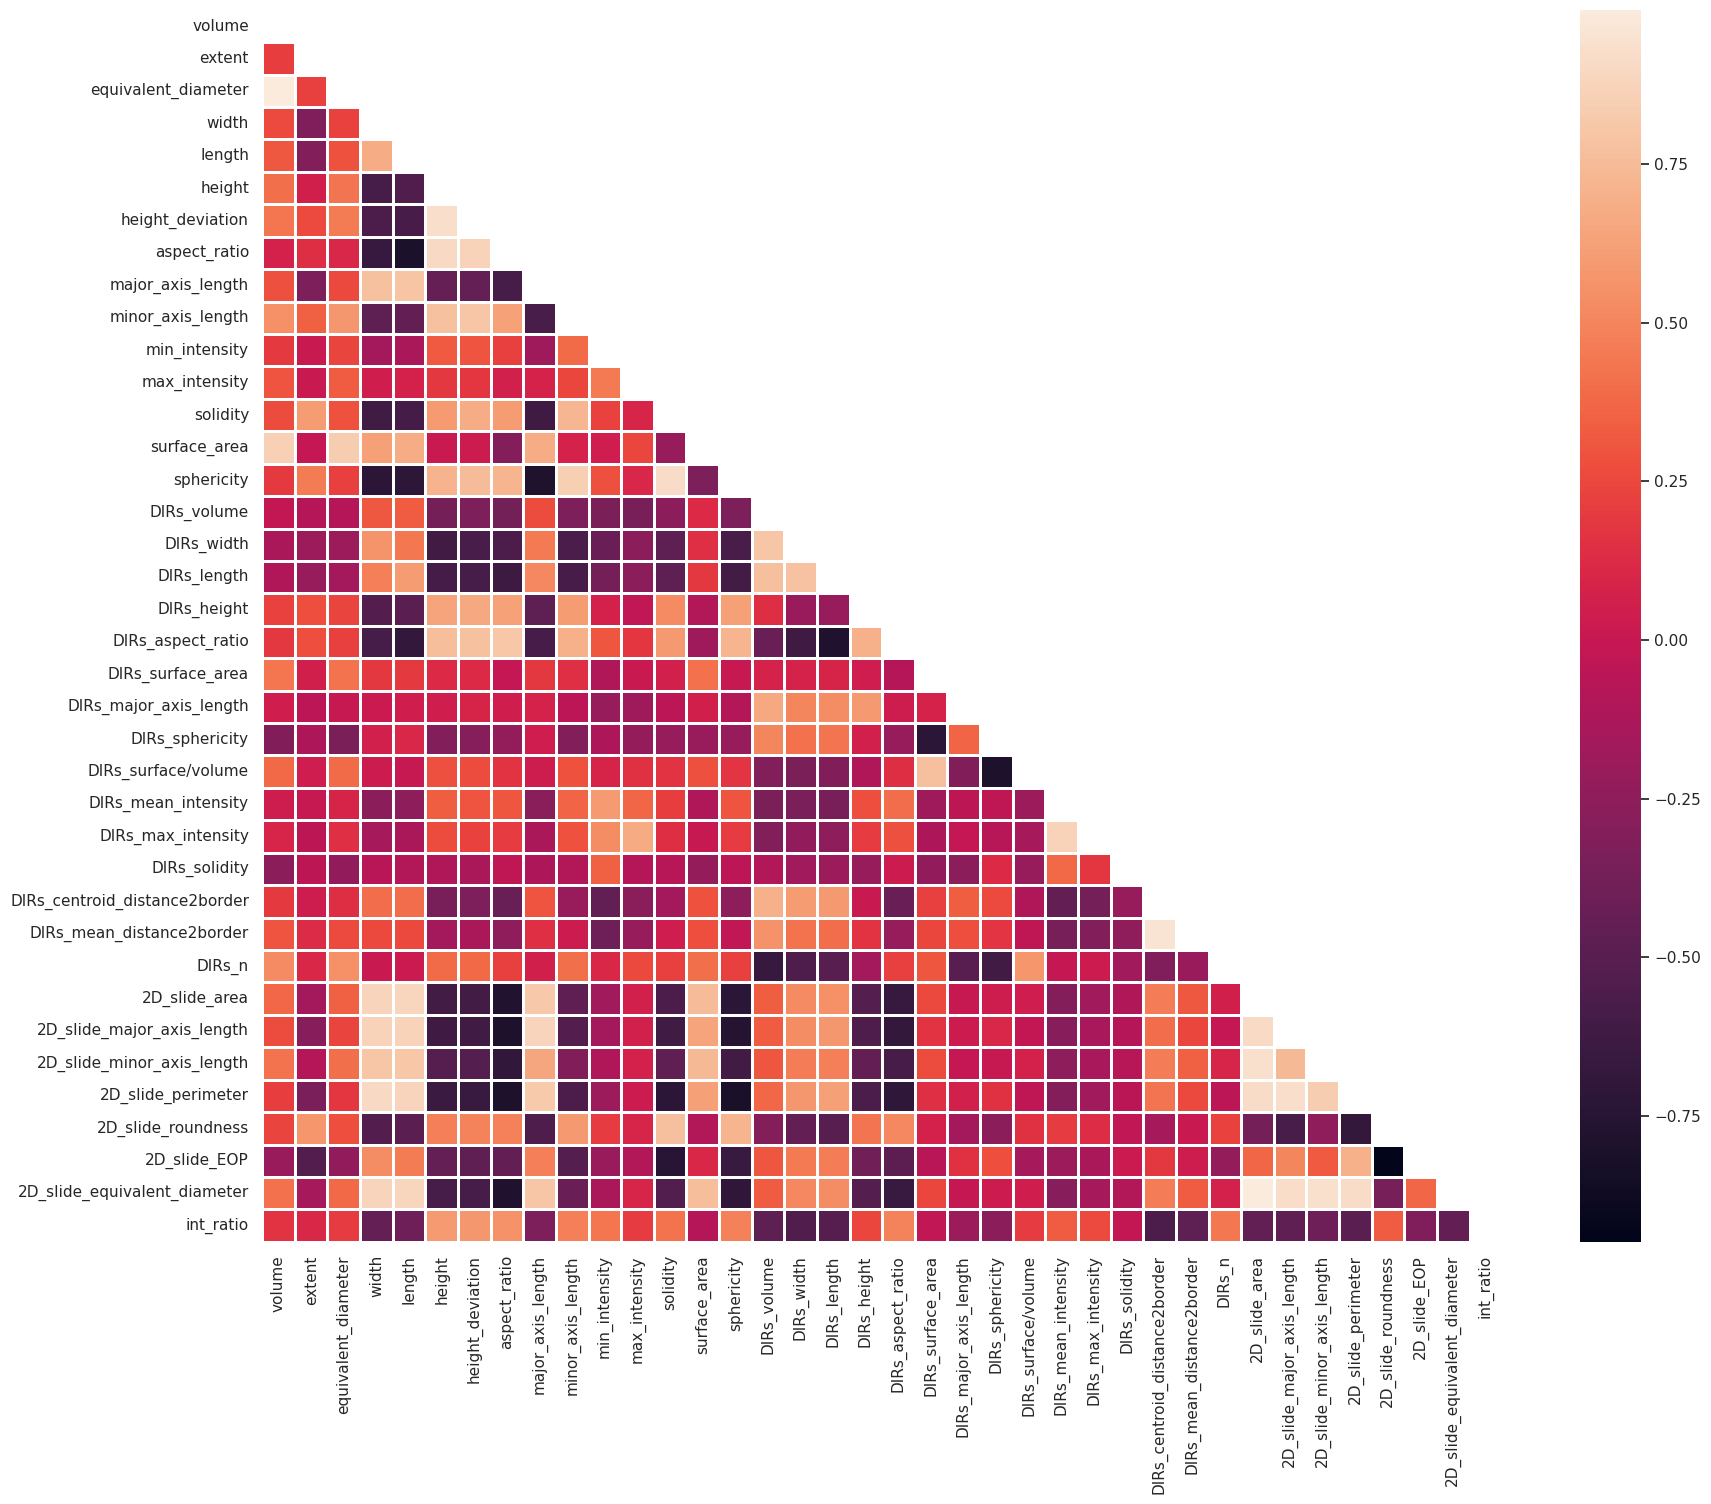

In [12]:
# Drop columns that contain NaN values
#nuc_df = nuc_df.dropna()
sns.set(rc={'figure.figsize':(20, 16)})
sns.set_style("whitegrid")

int_df = my_df[features[:-3]]

mask = np.triu(np.ones_like(int_df.corr(), dtype = bool))

# The features having co-efficient values close to one must be eliminated!!!
# We would be introducing redundancy
sns.heatmap(int_df.corr(), mask = mask, linewidths = 1, annot = False)
plt.show()